# 00 — Model inspection

This notebook documents the key changes to the original X-MACE model that were made:
the new autoencoder head, readout changes, decoder choices, and NAC loss and metrics. 

## 1. Original Model Overview

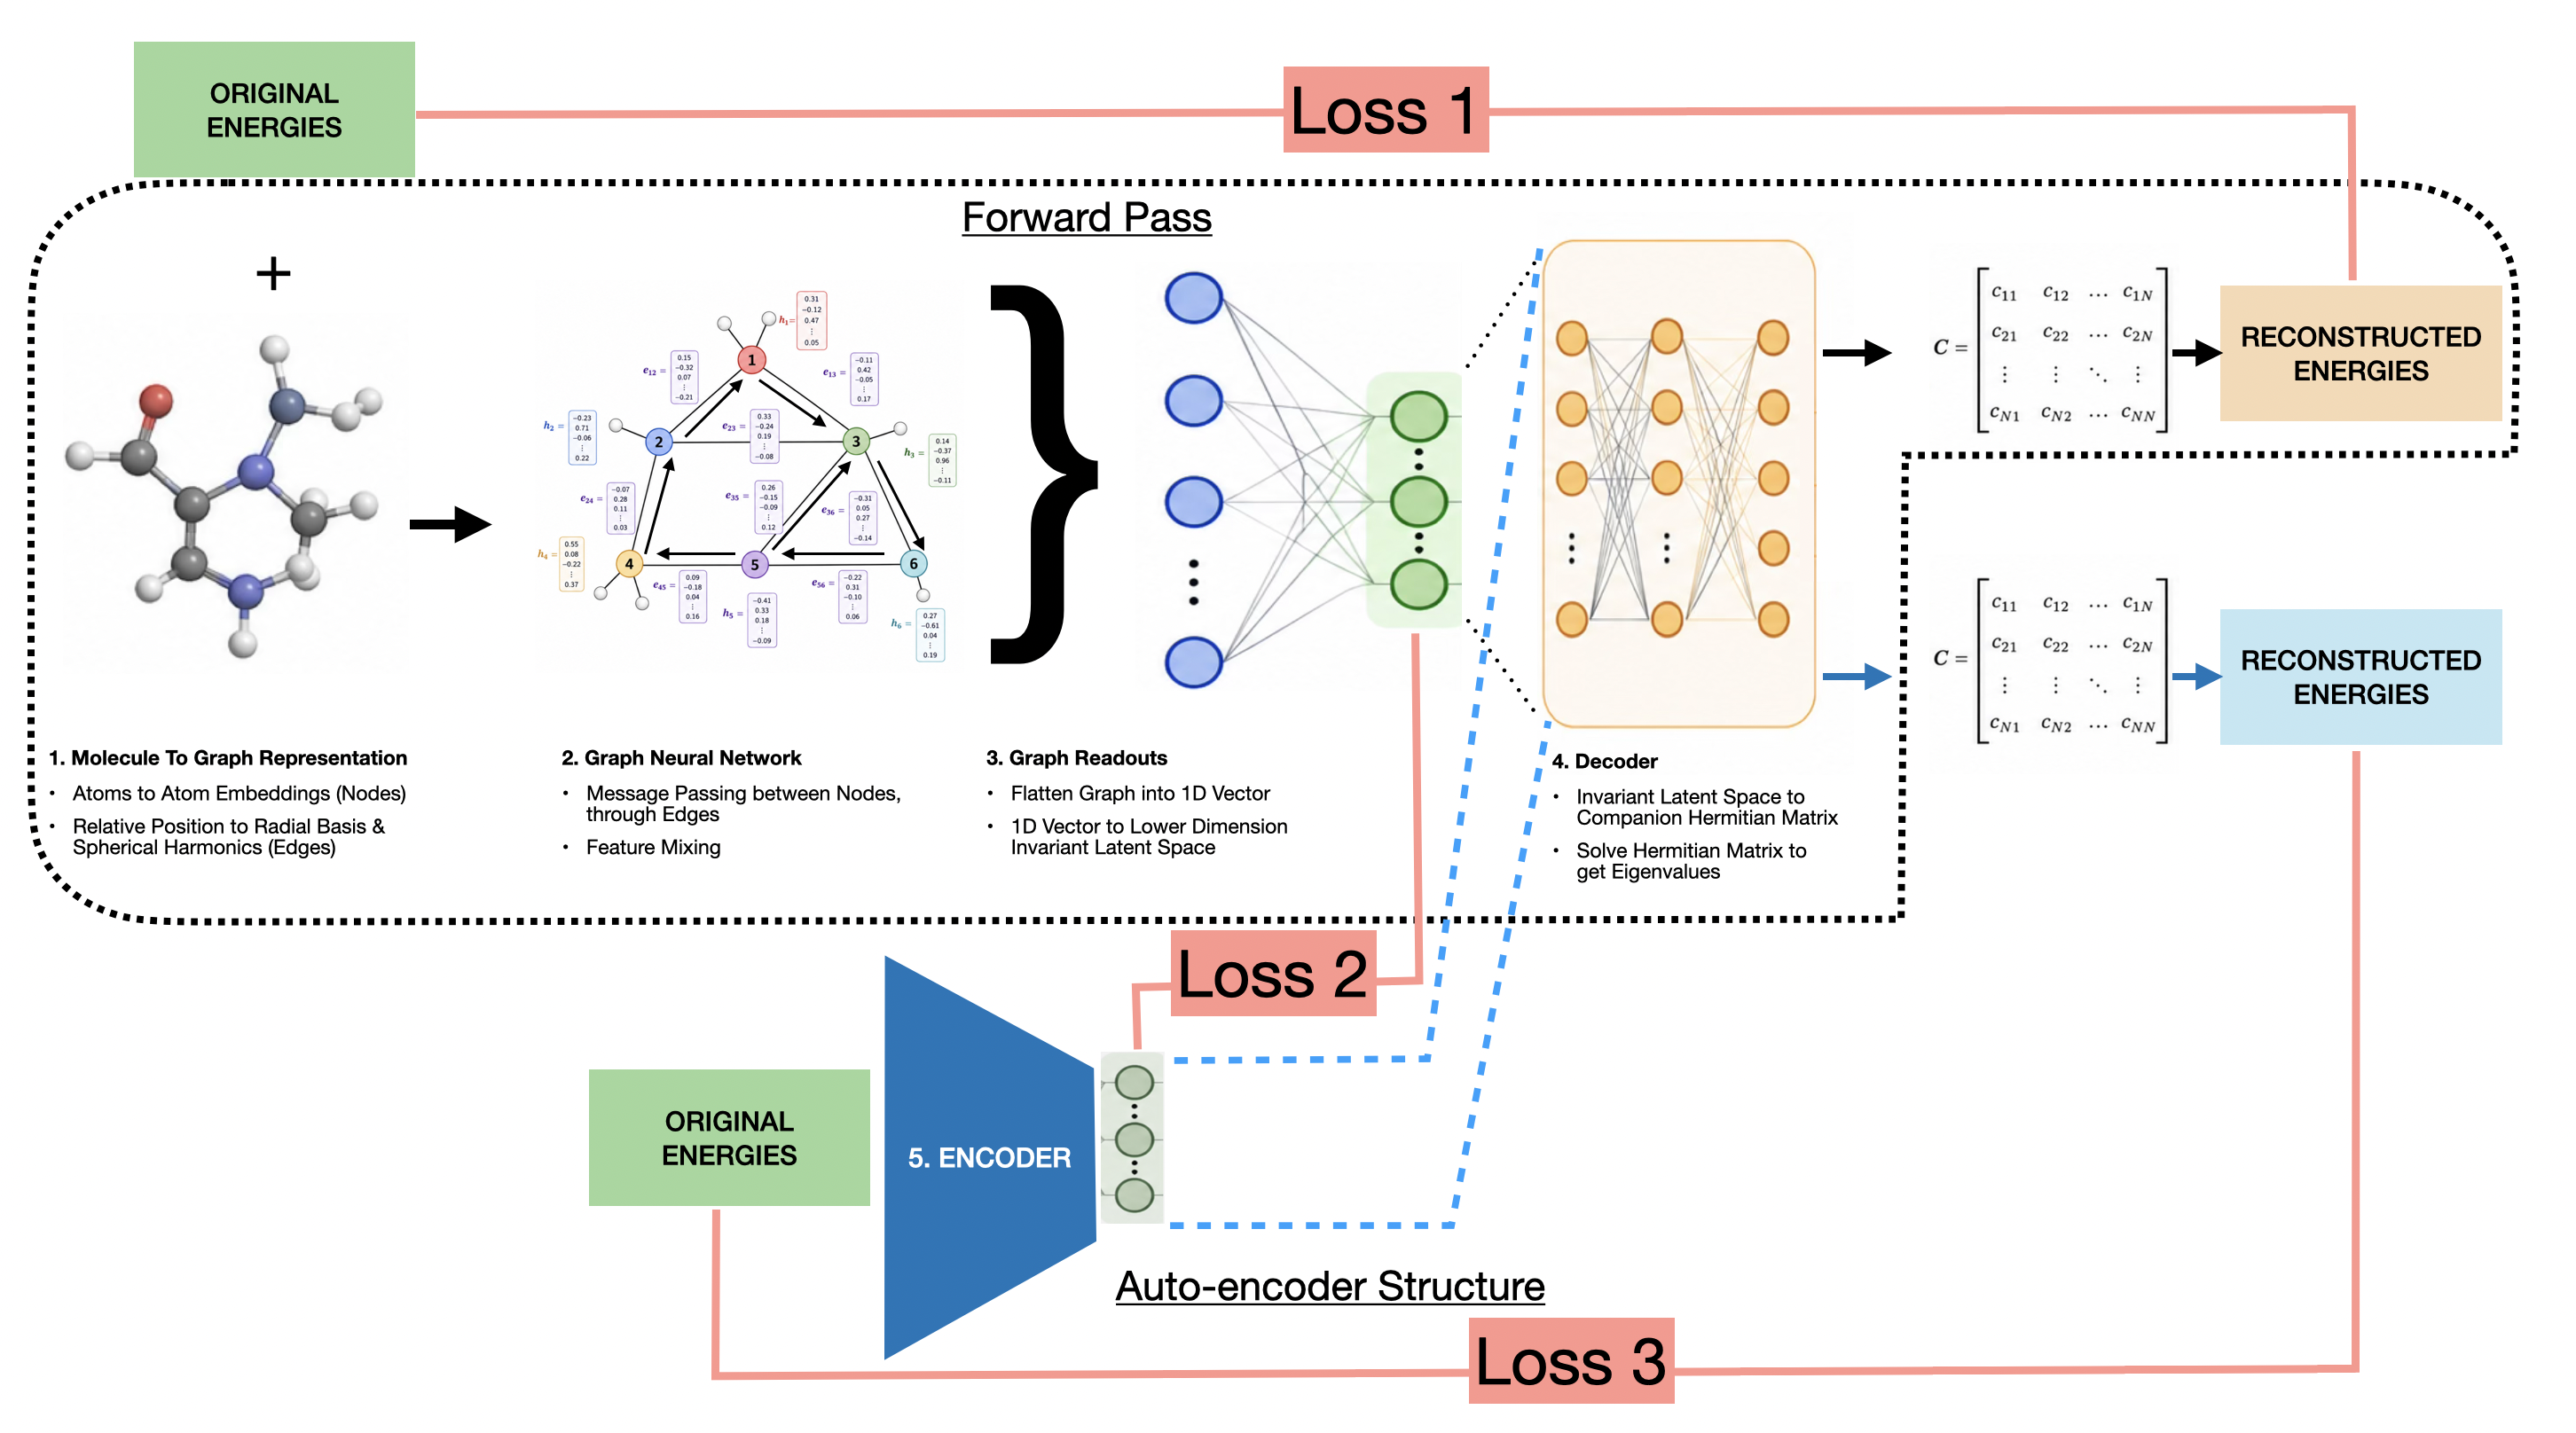

The original model has roughly the following connections 
1) Atoms in a molecule form graphs with atoms being converted into nodes via learned embeddings
2) The graph nodes and edges pass through interactions and products blocks to form learned features 
3) The readouts convert these features into 16D latent vectors (for energy predictions). Simultaneously an autoencoder also learns a separate 16D latent vector from the original energies. The alignment between the two latent vectors are part of the loss. Eventually decoder uses the 16D latent vector that came from the graph. 
4) Energies are computed by solving a predicted hermitian matrix and obtaining eigenvalues
5) Forces derived through autodiff of the network 
6) NACs use separate readout blocks that do not use the lower dimensional latent vectors 

## 2. New block: `AutoencoderHead`

Previously, the readouts, encoder, and decoder were separate attributes on the model. They are now grouped into one block:

```text
AutoencoderHead
├── invariant_readouts  → scalar latent values for energies
├── nac_readouts        → NAC vectors
├── socs_readouts       → spin–orbit coupling values
├── perm_encoder        → reference energies to latent values
└── perm_decoder        → latent values to energies
```

The encoder and decoder are not new; their grouping is. The key reason for doing this is so that subsequent multihead strategies can  **copy a complete head** while keeping the graph segment shared. 
Each head then can learn its own readouts, encoder, and decoder. 

For the current version, a single-head model also uses `model.autoencoder_heads[0]`for consistency.

### How data selects a head

The data builder attaches a head label to each geometry. The model uses that label to select a route (based on the strategy specified):

```text
Independent heads:
LF data → shared backbone → LF head
HF data → shared backbone → HF head

Base plus correction:
LF data → shared backbone → base head
HF data → shared backbone → base head + correction head
```

The **strategy defines the heads and routes**; the data label selects which route to use. In the current implementation, every geometry in one batch will have the same head label (settled by the data loader).

## 3. Readout and encoder changes

### 3a. Keep vector channels for NACs

Previously, the final interaction/product stage kept only scalar features. A scalar-only input cannot produce a nonzero vector through an equivariant linear readout, so the second interactions block could not produce any useful NAC contributions.

The current model keeps vector channels in the final stage and uses dedicated linear NAC readouts. Earlier and final stages can therefore both contribute to NAC predictions.

Energy readouts still produce scalars. Keeping vector features does **not** make energies depend on how the molecule is rotated: the energy decoder still receives an invariant latent vector.

### 3b. Encoder hidden width: 16 versus 128

The historical typo concerns the encoder's **hidden-layer width**: it used 16 values per hidden layer where 128 were intended. This is separate from the **latent dimension**, which controls the encoder's output size.

Ideally:
```text
Reference energies → encoder hidden layers of width 128 → latent vector of size 16
```

Ablation studies showed that this changed did improve the performance slightly. 

## 4. Two energy decoder options

Before the decoder only allowed energy predictions through the matrix. Now, the model factory supports another direct route through `energy_decoder`:

| Setting | How it predicts energies |
|---|---|
| `"matrix"` | Predicts entries of a symmetric tridiagonal matrix, then returns its sorted eigenvalues |
| `"direct"` | Uses a neural network to predict one energy for each state directly |

Still not 100% sure if this is better, not fully tested such that this is better or worse because the differences in errors seem to be within the experimental variances.

## 5. NAC loss and metrics: what changed and why

### Raw inputs, smooth supervision

Raw NACs can grow sharply when two states approach the same energy. Multiplying by the energy gap removes that explicit inverse-gap factor and gives a smoother training target:

```text
Raw reference NACs × absolute reference gaps → smooth targets
Predicted smooth NACs ÷ absolute predicted gaps → raw outputs
```

Both quantities are kept explicitly as `smooth_nacs` and `nacs`. Predicted gaps are floored at `1e-8` before division to avoid division by zero. Small-gap raw errors can still be large. **This threshold chosen to match their CLI implementation, but not optimised or tested rigorously yet.**

### Signs must be consistent within a geometry

An electronic wavefunction can be multiplied by −1 without changing the physical state. Its NACs change sign, so the loss should accept equivalent state-phase choices.

But those choices are linked. For three states, flipping state 1 changes pairs **(0,1) and (1,2) together**, while leaving (0,2) unchanged. The same pair sign must apply to every atom and Cartesian component in that geometry.

The earlier loss checked positive and negative signs independently for each atom/pair vector. That could report an artificially small error by accepting sign choices that no consistent set of state phases could produce.

### The current comparison

1. Enumerate valid state-phase assignments. Three states have four distinct assignments: fixing state 0's sign leaves two choices for each remaining state. Flipping all states together leaves every pair sign unchanged.
2. For each geometry, apply each assignment consistently across all atoms and pairs. Choose the assignment with the lowest mean squared error (MSE).
3. Train with the aligned **smooth-NAC MSE**. Report aligned **smooth and raw NAC mean absolute error (MAE)** during evaluation.

Each geometry chooses its own assignment; a batch does not share one sign choice. Raw and smooth reporting each perform their own alignment. Pair order is `(0,1), (0,2), (1,2)` for three states.

MSE is used for optimisation and sign selection. It avoids the outer square root in the earlier RMSE loss, whose derivative is singular at zero. MAE is retained for reporting because it expresses component errors in the quantity's own units. Phase alignment compares predictions with references; it is not an extra correction applied during ordinary prediction.